#### Nama: Mochammad Lintar Arya Dwiputra
#### NIM : 2024081032
#### Prodi : Sistem Informasi

# Tugas 4 - Feature Selection dan Feature Engineering untuk Rekomendasi Movie

Notebook ini menggunakan dataset `imdb_top_1000.csv`.

Tujuan:
- Menerapkan 2 teknik feature engineering: missing value handling dan one-hot encoding.
- Menerapkan 2 metode feature selection: univariate dan correlation heatmap.
- Menyusun fitur untuk sistem rekomendasi film berbasis kemiripan konten.

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity

pd.set_option("display.max_columns", 120)
sns.set_theme(style="whitegrid")

In [2]:
data_path = Path("Dataset") / "imdb_top_1000.csv"
df = pd.read_csv(data_path)

print(f"Ukuran data: {df.shape[0]} baris, {df.shape[1]} kolom")
df.head()

Ukuran data: 1000 baris, 16 kolom


,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,A,142 min,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,"28,341,469"
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972,A,175 min,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,"134,966,411"
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,"534,858,444"
3,https://m.media-amazon.com/images/M/MV5BMWMwMG...,The Godfather: Part II,1974,A,202 min,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,"57,300,000"
4,https://m.media-amazon.com/images/M/MV5BMWU4N2...,12 Angry Men,1957,U,96 min,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarria...,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,"4,360,000"


## Feature Engineering 1 - Missing Value Handling

Langkah:
1. Membersihkan kolom numerik yang masih berupa teks (`Runtime`, `Gross`, `Released_Year`).
2. Mengisi nilai kosong: median untuk numerik, mode untuk kategorikal.

In [3]:
df_fe = df.copy()

# Konversi kolom ke format numerik yang konsisten
df_fe["Runtime_min"] = pd.to_numeric(
    df_fe["Runtime"].str.replace(" min", "", regex=False),
    errors="coerce"
)
df_fe["Gross_num"] = pd.to_numeric(
    df_fe["Gross"].astype(str).str.replace(",", "", regex=False),
    errors="coerce"
)
df_fe["Meta_score"] = pd.to_numeric(df_fe["Meta_score"], errors="coerce")
df_fe["No_of_Votes"] = pd.to_numeric(df_fe["No_of_Votes"], errors="coerce")
df_fe["Released_Year_num"] = pd.to_numeric(df_fe["Released_Year"], errors="coerce")

cols_check = ["Certificate", "Runtime_min", "Gross_num", "Meta_score", "Released_Year_num"]
missing_before = df_fe[cols_check].isna().sum().rename("missing_before")

# Imputasi nilai hilang
df_fe["Certificate"] = df_fe["Certificate"].fillna(df_fe["Certificate"].mode(dropna=True)[0])
for col in ["Runtime_min", "Gross_num", "Meta_score", "No_of_Votes", "Released_Year_num"]:
    df_fe[col] = df_fe[col].fillna(df_fe[col].median())

missing_after = df_fe[cols_check].isna().sum().rename("missing_after")
pd.concat([missing_before, missing_after], axis=1)

,missing_before,missing_after
Certificate,101,0
Runtime_min,0,0
Gross_num,169,0
Meta_score,157,0
Released_Year_num,1,0


### Interpretasi Missing Value Handling

- Nilai kosong pada fitur penting berhasil ditangani sehingga data lebih stabil untuk analisis lanjutan.
- Imputasi median dipilih karena lebih robust terhadap outlier dibanding rata-rata.
- Pengisian `Certificate` dengan mode menjaga konsistensi kategori tanpa membuang baris data.

## Feature Engineering 2 - One-Hot Encoding

Encoding dilakukan pada:
- `Certificate` (single-label kategorikal)
- `Genre` (multi-label, dipisah dengan `, `)

In [4]:
cert_dummies = pd.get_dummies(df_fe["Certificate"], prefix="Cert")
genre_dummies = df_fe["Genre"].fillna("").str.get_dummies(sep=", ")

df_model = pd.concat([df_fe, cert_dummies, genre_dummies], axis=1)

one_hot_cols = cert_dummies.columns.tolist() + genre_dummies.columns.tolist()
print(f"Jumlah fitur hasil one-hot encoding: {len(one_hot_cols)}")
print("Contoh 15 fitur encoded:")
print(one_hot_cols[:15])

df_model[["Series_Title", "Certificate", "Genre"] + one_hot_cols[:8]].head()

Jumlah fitur hasil one-hot encoding: 37
Contoh 15 fitur encoded:
['Cert_16', 'Cert_A', 'Cert_Approved', 'Cert_G', 'Cert_GP', 'Cert_PG', 'Cert_PG-13', 'Cert_Passed', 'Cert_R', 'Cert_TV-14', 'Cert_TV-MA', 'Cert_TV-PG', 'Cert_U', 'Cert_U/A', 'Cert_UA']


,Series_Title,Certificate,Genre,Cert_16,Cert_A,Cert_Approved,Cert_G,Cert_GP,Cert_PG,Cert_PG-13,Cert_Passed
0,The Shawshank Redemption,A,Drama,False,True,False,False,False,False,False,False
1,The Godfather,A,"Crime, Drama",False,True,False,False,False,False,False,False
2,The Dark Knight,UA,"Action, Crime, Drama",False,False,False,False,False,False,False,False
3,The Godfather: Part II,A,"Crime, Drama",False,True,False,False,False,False,False,False
4,12 Angry Men,U,"Crime, Drama",False,False,False,False,False,False,False,False


### Interpretasi One-Hot Encoding

- Fitur kategorikal berhasil diubah menjadi numerik (0/1), sehingga bisa diproses algoritma machine learning.
- Genre multi-label memberi representasi konten film yang lebih kaya untuk kebutuhan rekomendasi.
- Setelah encoding, ruang fitur bertambah dan model dapat membedakan karakteristik film secara lebih detail.

## Feature Selection 1 - Univariate (SelectKBest)

Target yang dipakai: `IMDB_Rating`.

In [5]:
base_numeric_features = ["Released_Year_num", "Runtime_min", "Meta_score", "No_of_Votes", "Gross_num"]
feature_cols = base_numeric_features + one_hot_cols

X = df_model[feature_cols]
y = pd.to_numeric(df_model["IMDB_Rating"], errors="coerce")

selector = SelectKBest(score_func=f_regression, k=15)
selector.fit(X, y)

scores = np.nan_to_num(selector.scores_, nan=0.0)
score_table = pd.DataFrame({
    "feature": feature_cols,
    "score": scores
}).sort_values("score", ascending=False)

top_univariate = score_table.head(15).reset_index(drop=True)
top_univariate

,feature,score
0,No_of_Votes,323.861392
1,Meta_score,71.553117
2,Runtime_min,62.681634
3,Released_Year_num,17.524381
4,Cert_R,14.405018
5,Cert_PG-13,13.785063
6,Comedy,8.483556
7,Cert_A,8.035812
8,Gross_num,7.352499
9,Drama,3.529307


### Interpretasi Univariate

- Skor paling tinggi menunjukkan fitur yang paling berpengaruh secara individual terhadap `IMDB_Rating`.
- Fitur dengan skor atas dapat diprioritaskan agar model lebih fokus pada informasi yang paling relevan.
- Teknik ini efektif untuk menyaring fitur awal sebelum tahap modeling/rekomendasi lanjutan.

## Feature Selection 2 - Correlation Heatmap

Heatmap digunakan untuk melihat kekuatan hubungan antar fitur numerik dan target.

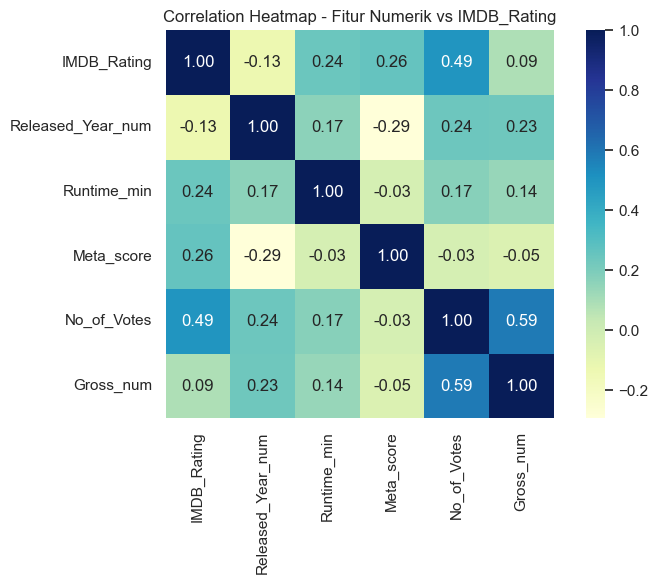

IMDB_Rating          1.000000
No_of_Votes          0.494979
Meta_score           0.258650
Runtime_min          0.243096
Released_Year_num   -0.131364
Gross_num            0.085518
Name: IMDB_Rating, dtype: float64

In [6]:
corr_cols = ["IMDB_Rating", "Released_Year_num", "Runtime_min", "Meta_score", "No_of_Votes", "Gross_num"]
corr_matrix = df_model[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="YlGnBu", fmt=".2f", square=True)
plt.title("Correlation Heatmap - Fitur Numerik vs IMDB_Rating")
plt.tight_layout()
plt.show()

corr_to_target = corr_matrix["IMDB_Rating"].sort_values(key=lambda s: s.abs(), ascending=False)
corr_to_target

### Interpretasi Correlation Heatmap

- Nilai korelasi mendekati +1 atau -1 menandakan hubungan linear yang kuat dengan `IMDB_Rating`.
- Fitur dengan korelasi sangat rendah cenderung kurang informatif untuk prediksi/ranking rating.
- Heatmap membantu mengecek kemungkinan fitur yang redundant sebelum membangun model rekomendasi.

## Contoh Rekomendasi Movie (Content-Based)

Rekomendasi dihitung menggunakan cosine similarity dari fitur hasil engineering dan fitur terpilih univariate.

In [7]:
selected_features = top_univariate["feature"].head(12).tolist()

X_rec = df_model[selected_features].copy()
scaler = StandardScaler()
X_rec_scaled = scaler.fit_transform(X_rec)

similarity_matrix = cosine_similarity(X_rec_scaled)

def recommend_movies(title, top_n=5):
    match_idx = df_model.index[df_model["Series_Title"].str.lower() == title.lower()]
    if len(match_idx) == 0:
        return pd.DataFrame({"Info": [f"Film '{title}' tidak ditemukan di dataset."]})

    idx = match_idx[0]
    sim_scores = list(enumerate(similarity_matrix[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    rec_indices = [i for i, _ in sim_scores[1: top_n + 1]]
    result = df_model.loc[rec_indices, ["Series_Title", "Genre", "IMDB_Rating", "Released_Year"]].copy()
    result.insert(0, "Query_Title", title)
    return result.reset_index(drop=True)

recommend_movies("Inception", top_n=5)

,Query_Title,Series_Title,Genre,IMDB_Rating,Released_Year
0,Inception,Batman Begins,"Action, Adventure",8.2,2005
1,Inception,Terminator 2: Judgment Day,"Action, Sci-Fi",8.5,1991
2,Inception,The Dark Knight Rises,"Action, Adventure",8.4,2012
3,Inception,Forrest Gump,"Drama, Romance",8.8,1994
4,Inception,The Dark Knight,"Action, Crime, Drama",9.0,2008


## Interpretasi Akhir

- Dua teknik feature engineering berhasil menyiapkan data agar siap dipakai model: missing value sudah ditangani dan fitur kategorikal sudah menjadi numerik.
- Dua metode feature selection membantu memilih fitur yang paling relevan berdasarkan skor univariate dan hubungan korelasi.
- Dengan fitur yang lebih informatif, hasil rekomendasi movie menjadi lebih terarah karena membandingkan film pada karakteristik konten yang penting.